In [21]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import Data 

Lets first load the issues data. This data includes all the values the model detected as possible issues and suggested a different label. 

In [7]:
df = pd.read_csv("../../outputs/analysis/data_quality/label_issues.csv")
df.sort_values(by = "confidence_in_given", ascending = False)

df_issues = df[df["given_label"] != df["suggested_label"]]
df_issues

,sample_index,measurement_id,given_label,suggested_label,confidence_in_given,confidence_in_suggested
0,175,24409454,10,5,8.031457e-12,0.564128
1,2189,24601200,5,9,1.932301e-08,0.562265
2,1241,24319685,4,8,2.427852e-08,0.556369
3,2021,24319683,5,8,3.493361e-06,0.455733
4,363,24601328,10,7,9.872978e-06,0.512644
...,...,...,...,...,...,...
1814,267,24727483,10,9,4.634575e-01,0.470652
1821,278,24719424,10,9,4.644137e-01,0.470014
1825,451,24316234,10,9,4.646442e-01,0.469860
1845,336,23894714,10,9,4.665105e-01,0.468610


Also lets load the original cod otolith database from the system This includes the metadata connected to the otoliths processed. 

In [34]:
df_age = pd.read_csv("/Users/joaodsm/Desktop/Joao Workspace/PhD Compilation/otolith-project/Data/cod_otolith_age.csv")

df_age["quarter"] = pd.to_datetime(df_age["dags"]).dt.quarter


Lets merge the two datasets while only mantaining selected columns from the second dataset. The columns kept are year and length. 

Below we have the issues by year distribution 

<Axes: xlabel='ar'>

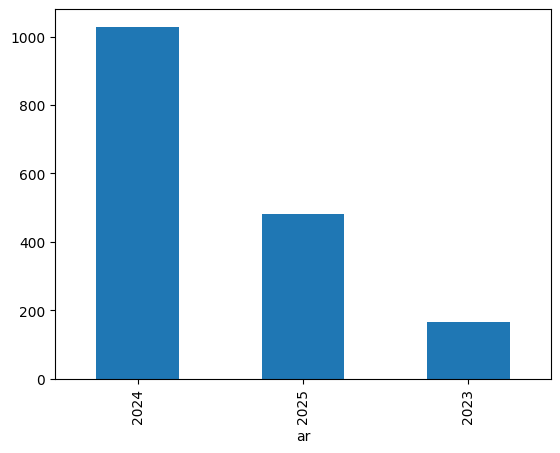

In [15]:


# If you need to specify different column names for the merge key:
df_merged = df_issues.merge(df_age, left_on='measurement_id', right_on='maeling_id', how='inner')[["lengd", "ar", "aldur"]]

df_merged["ar"].value_counts().plot(kind = "bar")


## Full Data Set Analysis

In [41]:
df_age

,Unnamed: 0,maeling_id,synis_id,tegund_nr,hlutfall,lengd,kyn_nr,kynthroski_nr,aldur,fjoldi,...,lofthiti,loftvog,straumstefna,straumhradi,sjondypi,veidisvaedi,hnattstada,stada_stodvar_nr,umhverfi_aths,quarter
0,1,21513884,507347,1,NaN,74,1.0,1.0,5.0,1,...,5.0,NaN,NaN,NaN,NaN,Hálsar,-1,NaN,NaN,1
1,2,21513891,507744,1,NaN,80,2.0,1.0,6.0,1,...,8.0,NaN,NaN,NaN,15.0,Stokksnesgrunn,-1,NaN,NaN,2
2,3,21513892,507737,1,NaN,64,2.0,1.0,4.0,1,...,8.0,NaN,NaN,NaN,5.0,Dilkneshryggur,-1,NaN,NaN,2
3,4,21513893,507735,1,NaN,84,1.0,1.0,8.0,1,...,8.0,NaN,NaN,NaN,5.0,Dilkneshryggur,-1,NaN,NaN,2
4,5,21513894,507733,1,NaN,71,2.0,1.0,6.0,1,...,8.0,NaN,NaN,NaN,5.0,Dilkneshryggur,-1,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16544,16545,24786769,555108,1,NaN,39,1.0,1.0,4.0,1,...,4.2,1026.0,NaN,NaN,NaN,NaN,-1,NaN,NaN,1
16545,16546,24786772,555108,1,NaN,58,2.0,2.0,5.0,1,...,4.2,1026.0,NaN,NaN,NaN,NaN,-1,NaN,NaN,1
16546,16547,24786775,555108,1,NaN,96,2.0,2.0,7.0,1,...,4.2,1026.0,NaN,NaN,NaN,NaN,-1,NaN,NaN,1
16547,16548,24787345,555109,1,NaN,46,2.0,1.0,4.0,1,...,4.5,1024.0,NaN,NaN,NaN,NaN,-1,NaN,NaN,1


In [42]:
import os

from pandas import value_counts 

image_path = "../../otolith_images"
age_folders = os.listdir(image_path)

images_list = []

for folder in age_folders: 
    if folder[0] != ".": 
        # Get folder path
        folder_path = os.path.join(image_path, folder)
        # Get images list as integers without the file extension
        images_list += [int(image.split(".")[0]) for image in os.listdir(folder_path)]

# Annual counts for the full data
df_age = df_age[df_age["maeling_id"].isin(images_list)]
year_counts = df_age["ar"].value_counts()

# Annual Issues counts
year_issues_counts = df_merged["ar"].value_counts()

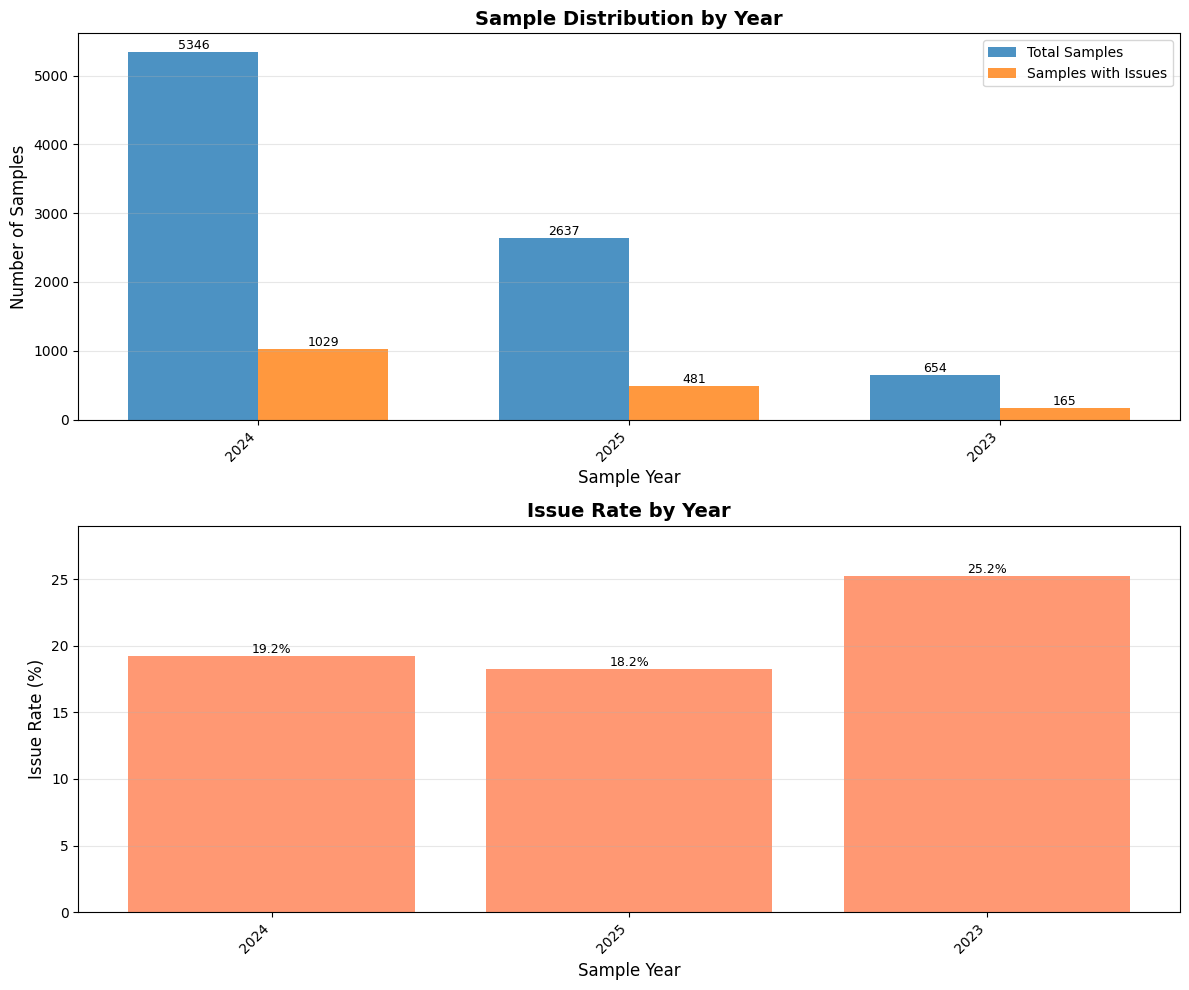

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Sample counts
x = year_counts.index.values
width = 0.35
x_pos = np.arange(len(x))

bars1 = ax1.bar(x_pos - width/2, year_counts.values, width, 
                label='Total Samples', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, year_issues_counts.values, width,
                label='Samples with Issues', alpha=0.8)

ax1.set_xlabel('Sample Year', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x, rotation=45, ha='right')
ax1.set_title('Sample Distribution by Year', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9)

# Plot 2: Issue rate proportion
proportions = (year_issues_counts / year_counts * 100).fillna(0)
bars3 = ax2.bar(x_pos, proportions.values, color='coral', alpha=0.8)

ax2.set_xlabel('Sample Year', fontsize=12)
ax2.set_ylabel('Issue Rate (%)', fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x, rotation=45, ha='right')
ax2.set_title('Issue Rate by Year', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(proportions.values) * 1.15)  # Add 15% headroom for labels

# Add percentage labels
for i, bar in enumerate(bars3):
    height = bar.get_height()
    if height > 0:
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
df_age

,Unnamed: 0,maeling_id,synis_id,tegund_nr,hlutfall,lengd,kyn_nr,kynthroski_nr,aldur,fjoldi,...,yfirbordshiti,lofthiti,loftvog,straumstefna,straumhradi,sjondypi,veidisvaedi,hnattstada,stada_stodvar_nr,umhverfi_aths
560,561,23625439,542618,1,NaN,69,1.0,4.0,6.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Sporðagrunn,-1,NaN,NaN
561,562,23625441,542618,1,NaN,66,2.0,1.0,7.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Sporðagrunn,-1,NaN,NaN
562,563,23625442,542618,1,NaN,72,1.0,3.0,7.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Sporðagrunn,-1,NaN,NaN
563,564,23625445,542618,1,NaN,65,2.0,1.0,5.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Sporðagrunn,-1,NaN,NaN
564,565,23625447,542618,1,NaN,68,2.0,1.0,6.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Sporðagrunn,-1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16536,16537,24785922,555106,1,NaN,83,2.0,52.0,6.0,1,...,6.3,1.6,1025.0,NaN,NaN,NaN,NaN,-1,NaN,NaN
16537,16538,24785923,555106,1,NaN,61,2.0,2.0,5.0,1,...,6.3,1.6,1025.0,NaN,NaN,NaN,NaN,-1,NaN,NaN
16538,16539,24785995,555106,1,NaN,42,1.0,1.0,4.0,1,...,6.3,1.6,1025.0,NaN,NaN,NaN,NaN,-1,NaN,NaN
16539,16540,24786305,555107,1,NaN,24,1.0,1.0,2.0,1,...,6.4,2.5,1025.0,NaN,NaN,NaN,NaN,-1,NaN,NaN


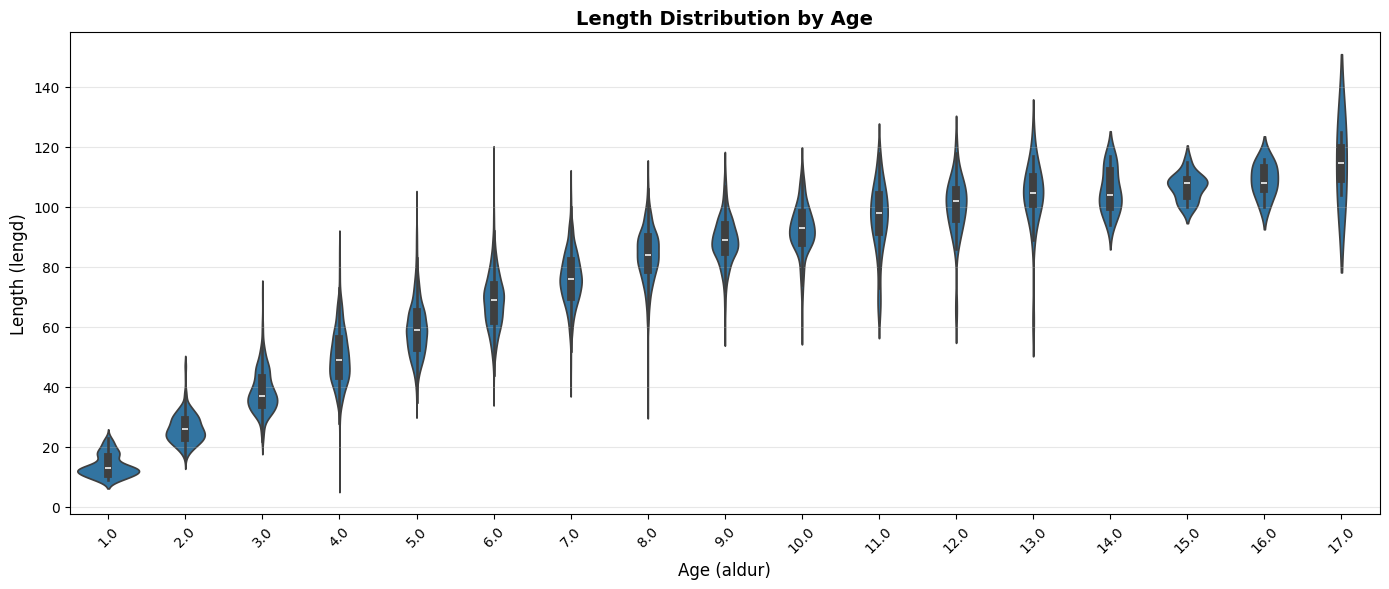

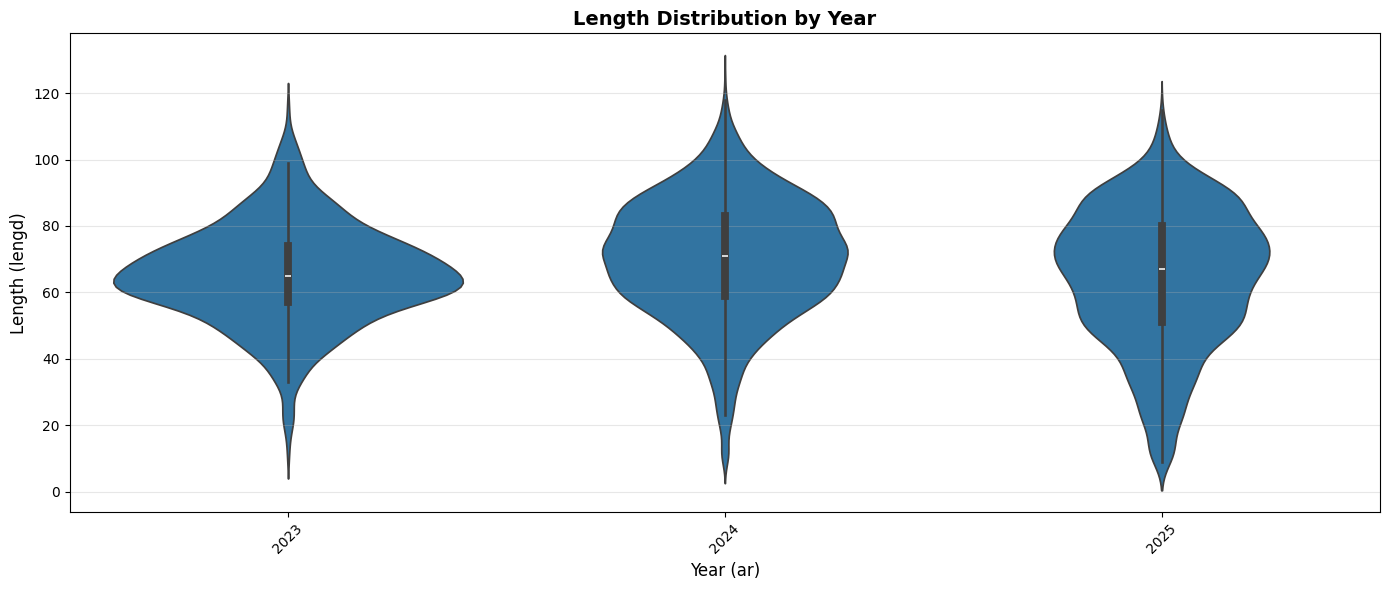

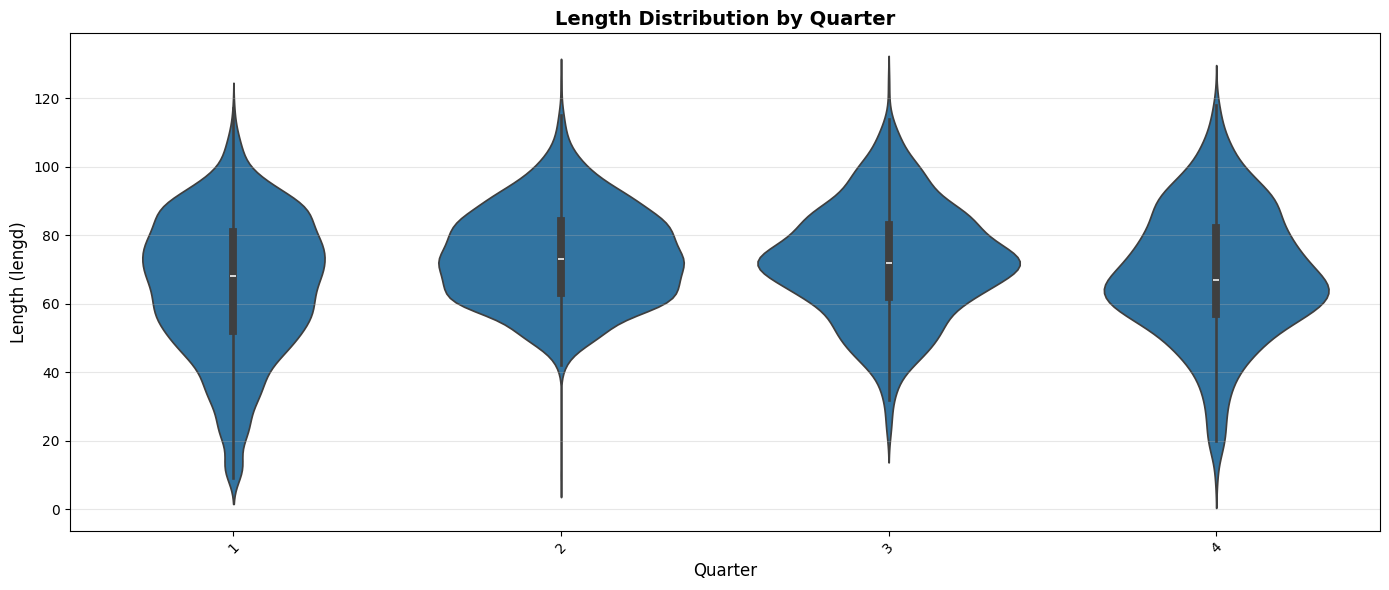

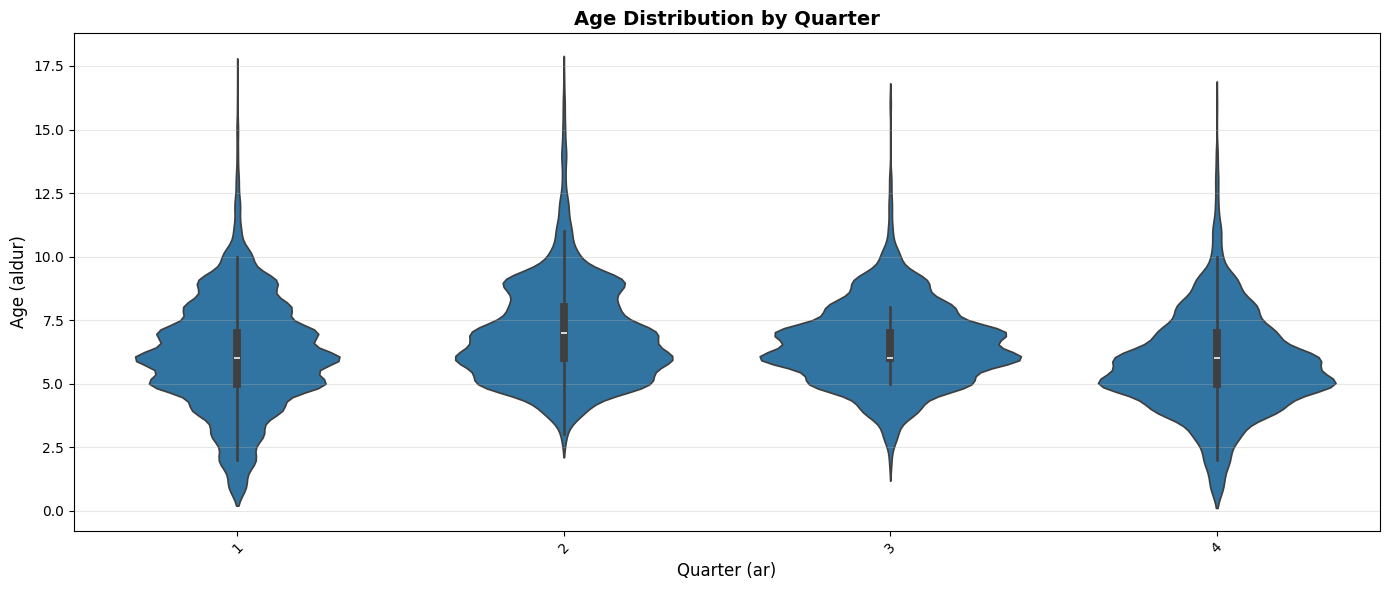

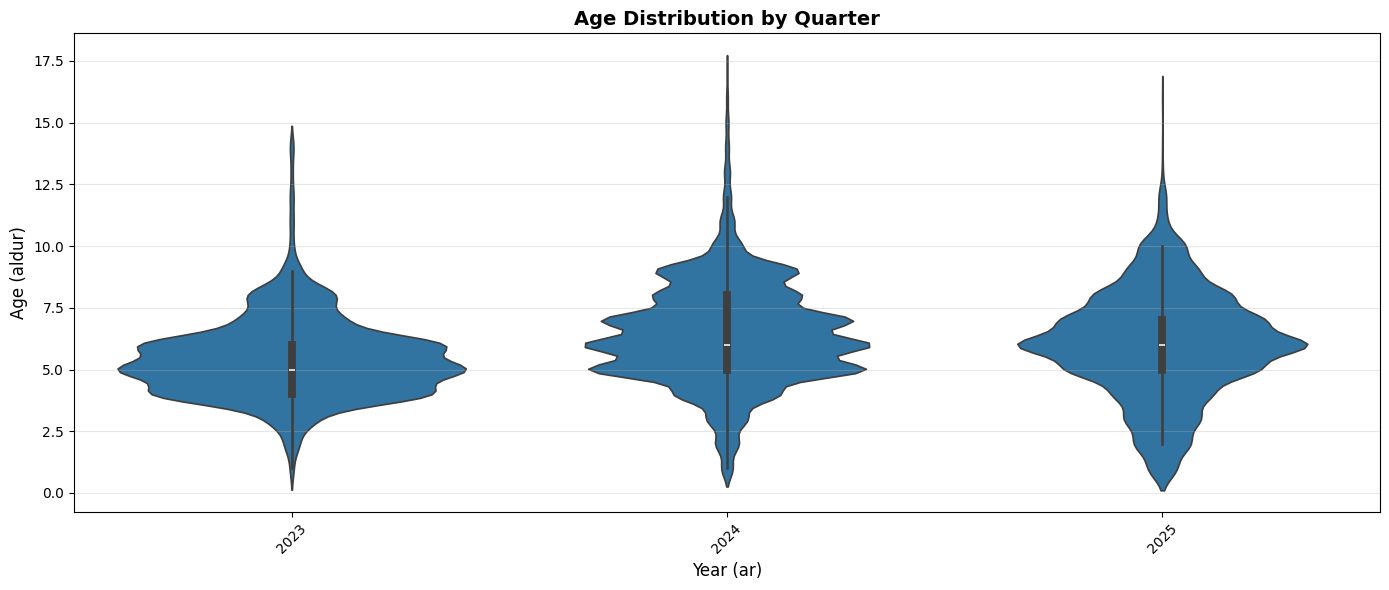

In [43]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=df_age, x='aldur', y='lengd')
plt.xlabel('Age (aldur)', fontsize=12)
plt.ylabel('Length (lengd)', fontsize=12)
plt.title('Length Distribution by Age', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.violinplot(data=df_age, x='ar', y='lengd')
plt.xlabel('Year (ar)', fontsize=12)
plt.ylabel('Length (lengd)', fontsize=12)
plt.title('Length Distribution by Year', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.violinplot(data=df_age, x='quarter', y='lengd')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Length (lengd)', fontsize=12)
plt.title('Length Distribution by Quarter', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.violinplot(data=df_age, x='quarter', y='aldur')
plt.xlabel('Quarter (ar)', fontsize=12)
plt.ylabel('Age (aldur)', fontsize=12)
plt.title('Age Distribution by Quarter', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 6))
sns.violinplot(data=df_age, x='ar', y='aldur')
plt.xlabel('Year (ar)', fontsize=12)
plt.ylabel('Age (aldur)', fontsize=12)
plt.title('Age Distribution by Quarter', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()